# SGR 1935+2154 Periodicity Search

This notebook is part of the code backup for **"Revisit the periodicity of SGR J1935+2154 bursts with updated sample" (Xie et al. 2022)**. It recreates the periodicity search figures and statistics described in the paper.

- **Paper reference**: MNRAS 517, 3854-3863 — DOI [10.1093/mnras/stac2918](https://doi.org/10.1093/mnras/stac2918)
- **Branch note**: This branch reorganizes the original scripts with AI assistance. To inspect the untouched main branch code, visit the [original commit](https://github.com/xiesl97/sgr1935-periodicity-search/tree/e4d0aae38060d52573491dfb39223e54697620c7).
- **Inputs**: Burst catalogs and windows curated in Xie et al. (2022), plus simulation outputs shipped with the repository.
- **How to run**: Install `requirements.txt`, then execute the cells sequentially (Kernel → Restart & Run All) to regenerate the plots and tables.

Use this notebook together with `periodicity_analysis.py` when reproducing the analysis reported in the publication.

In [ ]:
"""
PART 1: Import Libraries and Define Core Functions
====================================================
Import all necessary libraries and define fundamental functions for periodicity analysis.
"""

import os
import math
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.collections as collections
import multiprocessing as mp
from astropy.time import Time
from astropy.timeseries import LombScargle
from astropy.stats import bayesian_blocks
from functools import partial
from gbm.time import Met
from scipy.signal import argrelextrema, find_peaks
from scipy.special import gammaln
from scipy import interpolate
from sklearn import preprocessing
from numba import jit, njit
from numba.typed import List

# Suppress warnings for cleaner output
np.seterr(divide='ignore', invalid='ignore')

# Global epsilon for numerical stability
epsilon = 1e-6

# ==============================================
# Core Mathematical Functions
# ==============================================

@njit(nogil=True)
def FoldPhase(T, T0, P):
    """
    Fold time series into phase space for a given period.
    
    Parameters:
        T (ndarray): Array of times (MJD)
        T0 (float): Reference epoch (MJD)
        P (float): Period in days
    
    Returns:
        phi (ndarray): Array of phases in range [0, 1)
    """
    phi = (T - T0) / P - np.floor((T - T0) / P)
    return phi


def Exposure(mjd_ot, observe_time, index0, index1, T0, phasebins, period):
    """
    Calculate exposure correction for each phase bin.
    
    Accounts for gaps in observation coverage when calculating statistics.
    
    Parameters:
        mjd_ot: Array of MJD times with observation data
        observe_time: Array of observation times for each mjd_ot entry
        index0, index1: Index range to consider
        T0: Reference epoch (MJD)
        phasebins: Number of phase bins
        period: Period for phase folding (days)
    
    Returns:
        exposures: Array of exposure times in each phase bin
    """
    Times = mjd_ot[index0:index1+1]
    observe_times = observe_time[index0:index1+1]
    phis = FoldPhase(Times, T0, period)
    sortindex = np.argsort(phis)
    phis = phis[sortindex]
    observe_times = observe_times[sortindex]
    
    exposures = np.zeros(phasebins)
    phasebin_size = 1.0 / phasebins
    
    for i in range(phasebins):
        phase_start = i * phasebin_size
        phase_end = (i + 1) * phasebin_size
        index = np.where((phase_start < phis) & (phis < phase_end) & (observe_times != 1))[0]
        
        if len(index) > 0:
            exposures[i] = np.sum(observe_times[index]) / len(index)
    
    return exposures


def PearsonChiSquare(phasebins, phi, period, exposures):
    """
    Calculate reduced Pearson chi-square statistic.
    
    χ²_reduced = Σ[(N_i - expected_i)² / expected_i] / (phasebins - 1)
    
    Parameters:
        phasebins: Number of phase bins
        phi: Array of phases
        period: Period (days)
        exposures: Exposure time in each phase bin
    
    Returns:
        chi2_reduced: Reduced chi-square statistic value
    """
    phasebin = 1.0 / phasebins
    Ni, bins = np.histogram(phi, bins=np.arange(0., 1. + phasebin, phasebin))
    p = np.sum(Ni) / np.sum(exposures)
    
    chi2 = np.zeros(phasebins)
    for i in range(phasebins):
        chi2[i] = (Ni[i] - p * exposures[i])**2 / (p * exposures[i] + epsilon)
    
    chi2_reduced = np.sum(chi2) / (phasebins - 1)
    return chi2_reduced


# ==============================================
# C-Statistic Helper Functions
# ==============================================

def Poissonk(miu, k):
    """Calculate Poisson probability P(k; μ)."""
    return np.exp(-miu) * miu**k / np.math.factorial(k)


def Cexpeted(miu):
    """
    Calculate expected C statistic value using piecewise approximations.
    
    Based on analytical derivations and numerical fits for different μ ranges.
    Reference: Cash (1979) and subsequent improvements.
    
    Parameters:
        miu (float): Mean value (μ)
    
    Returns:
        Ce (float): Expected C statistic
    """
    if (0 <= miu) & (miu <= 0.5):
        Ce = -0.25*miu**3 + 1.38*miu**2 - 2*miu*np.log(miu + epsilon)
    elif (0.5 < miu) & (miu <= 2):
        Ce = -0.00335*miu**5 + 0.04259*miu**4 - 0.27331*miu**3 + 1.381*miu**2 - 2*miu*np.log(miu + epsilon)
    elif (2 < miu) & (miu <= 5):
        Ce = 1.019275 + 0.1345*miu**(0.461 - 0.9*np.log(miu + epsilon))
    elif (5 < miu) & (miu <= 10):
        Ce = 1.00624 + 0.604/(miu**1.68)
    else:  # miu > 10
        Ce = 1 + 0.1649/miu + 0.226/(miu**2)
    return Ce


def Cvariance(miu):
    """
    Calculate variance of C statistic using piecewise approximations.
    
    Accounts for low-count and high-count regimes with appropriate approximations.
    
    Parameters:
        miu (float): Mean value (μ)
    
    Returns:
        Cv (float): Variance of C statistic
    """
    if (0 <= miu) & (miu <= 0.1):
        Sv = 4 * np.sum([Poissonk(miu, k) * (miu - k + k*np.log(k/miu + epsilon))**2 for k in range(1, 5)])
        Cv = Sv - Cexpeted(miu)**2
    elif (0.1 < miu) & (miu <= 0.2):
        Cv = -262*miu**4 + 195*miu**3 - 51.24*miu**2 + 4.34*miu + 0.77005
    elif (0.2 < miu) & (miu <= 0.3):
        Cv = 4.23*miu**2 - 2.8254*miu + 1.12522
    elif (0.3 < miu) & (miu <= 0.5):
        Cv = -3.7*miu**3 + 7.328*miu**2 - 3.6926*miu + 1.20641
    elif (0.5 < miu) & (miu <= 1):
        Cv = 1.28*miu**4 - 5.191*miu**3 + 7.666*miu**2 - 3.5446*miu + 1.15431
    elif (1 < miu) & (miu <= 2):
        Cv = 0.1125*miu**4 - 0.641*miu**3 + 0.859*miu**2 + 1.0914*miu - 0.05748
    elif (2 < miu) & (miu <= 3):
        Cv = 0.089*miu**3 - 0.872*miu**2 + 2.8422*miu - 0.67539
    elif (3 < miu) & (miu <= 5):
        Cv = 2.12336 + 0.012202*miu**(5.717 - 2.6*np.log(miu + epsilon))
    elif (5 < miu) & (miu <= 10):
        Cv = 2.05159 + 0.331*miu**(1.343 - np.log(miu + epsilon))
    else:  # miu > 10
        Cv = 12/(miu**3) + 0.79/(miu**2) + 0.6747/miu + 2
    return Cv


def Cstat(phasebins, phi, period, exposures):
    """
    Calculate normalized C statistic for periodicity test.
    
    C = [2·Σ(c_i) - Σ(C_e,i)] / √[Σ(C_v,i)]
    
    where:
        c_i = Cash statistic for bin i
        C_e,i = expected value for bin i
        C_v,i = variance for bin i
    
    Parameters:
        phasebins: Number of phase bins
        phi: Array of phases
        period: Period (days)
        exposures: Exposure time in each phase bin
    
    Returns:
        C_Ce_Cv: Normalized C statistic value
    """
    phasebin = 1.0 / phasebins
    Ni, bins = np.histogram(phi, bins=np.arange(0., 1. + phasebin, phasebin))
    p = np.sum(Ni) / np.sum(exposures)
    
    cstat = np.zeros(phasebins)
    Ce = np.zeros(phasebins)
    Cv = np.zeros(phasebins)
    
    for i in range(phasebins):
        if Ni[i] == 0:
            cstat[i] = p * exposures[i]
        else:
            cstat[i] = p * exposures[i] - Ni[i] + Ni[i] * np.log(epsilon + Ni[i] / (p * exposures[i]))
        
        Ce[i] = Cexpeted(p * exposures[i])
        Cv[i] = Cvariance(p * exposures[i])
    
    C_Ce_Cv = (2 * np.sum(cstat) - np.sum(Ce)) / np.sqrt(np.sum(Cv) + epsilon)
    return C_Ce_Cv

In [ ]:
"""
PART 2: Load Data
=================
Load burst time series data, observation times, and simulation results.
"""

# Time conversion precision (decimal places)
n = 9

# ========================
# Load Burst Time Series
# ========================

# Load burst data from observation lists
Data_for_plot = pd.read_excel('List_SGR1935.xlsx', sheet_name=0)
utc_for_plot = Data_for_plot.iloc[:, 0].values
mjd_for_plot = np.array([
    math.floor(Time(utc_for_plot[i], format='isot', scale='utc').mjd * (10**n)) / (10**n) 
    for i in range(len(utc_for_plot))
])
flag = np.array(Data_for_plot.iloc[:, 2].values)

# ========================
# Load Observation Times
# ========================

# Daily binned observation windows
OT = pd.read_excel('ObserveTime.xlsx', sheet_name='Bin1day')
mjd_ot = np.array(OT['Time_MJD'])
observe_time = np.array(OT['Observe_Time'])

# Finer binning (0.05 day) for detailed analysis
OT_bin = pd.read_excel('ObserveTime.xlsx', sheet_name='Bin0.05day')
mjd_bin_ot = np.array(OT_bin['Time_MJD'])
observe_bin_time = np.array(OT_bin['Observe_Time'])

# ========================
# Load Simulation Data
# ========================

# Simulate periodogram from observation window artifacts
data = pd.read_csv('simulation.csv')
simu_time_series, simu_signal = data['simu_time_series'], data['simu_signal']
del data

# Calculate Lomb-Scargle periodogram for simulation
simu_frequency, simu_power = LombScargle(
    simu_time_series - 56658, 
    simu_signal
).autopower(
    minimum_frequency=1/1000,
    maximum_frequency=1/2,
    normalization='standard'
)

# ========================
# Define Sample Sets
# ========================

# Sample A: Non-candidate bursts (likely real detections)
mjd_sampleA = mjd_for_plot[np.where(flag != 'Candidate')]

# Sample B: All bursts
mjd_sampleB = mjd_for_plot

print(f"Sample A: {len(mjd_sampleA)} bursts")
print(f"Sample B: {len(mjd_sampleB)} bursts")

In [ ]:
"""
PART 3: Prepare Time Series and Calculate Burst Rates
=====================================================
Bin burst data and normalize by exposure time to get burst rates.
"""

# ========================
# Time Constants
# ========================

T0_A = 56658      # Reference epoch for Sample A (2014-01-01)
T0_B = 54771      # Reference epoch for Sample B (2008-11-01)
T100 = 59599      # End time for analysis (2022-01-20)
Bin = 0.05        # Time bin size in days

# ========================
# Sample A Processing
# ========================

print("Processing Sample A...")

# Create time series relative to T0_A
time_series_A = np.array(mjd_sampleA) - T0_A

# Bin the burst times
rates_A, times_A = np.histogram(
    time_series_A,
    bins=np.round(np.arange(0, T100 - T0_A, Bin), len(str(Bin).split(".")[1]))
)
times_A = times_A[:-1]

# Normalize observation times to bin size
observe_bin_time = observe_bin_time / Bin

# Find index ranges
index0_A = np.where(T0_A <= mjd_ot)[0][0]
index1_A = np.where(mjd_ot <= T100)[0][-1]
index2_A = np.where(T0_A <= mjd_bin_ot)[0][0]
index3_A = np.where(mjd_bin_ot <= T100)[0][-1]

# Verify bin alignment
for i in range(len(times_A)):
    if times_A[i] + T0_A != mjd_bin_ot[index2_A + i]:
        print(f"Bin mismatch at index {i}")
        raise ValueError("Time bin alignment error in Sample A")

# Normalize rates by exposure
norm_rates_A = np.zeros(len(rates_A))
for i in range(len(rates_A)):
    if observe_bin_time[index2_A + i] == 0:
        continue
    else:
        norm_rates_A[i] = rates_A[i] / observe_bin_time[index2_A + i]

print(f"Sample A: {len(rates_A)} time bins, {np.sum(rates_A)} total bursts")

# ========================
# Sample B Processing
# ========================

print("Processing Sample B...")

# Create time series relative to T0_B
time_series_B = np.array(mjd_sampleB) - T0_B

# Bin the burst times
rates_B, times_B = np.histogram(
    time_series_B,
    bins=np.round(np.arange(0, T100 - T0_B, Bin), len(str(Bin).split(".")[1]))
)
times_B = times_B[:-1]

# Find index ranges
index0_B = np.where(T0_B <= mjd_ot)[0][0]
index1_B = np.where(mjd_ot <= T100)[0][-1]
index2_B = np.where(T0_B <= mjd_bin_ot)[0][0]
index3_B = np.where(mjd_bin_ot <= T100)[0][-1]

# Verify bin alignment
for i in range(len(times_B)):
    if times_B[i] + T0_B != mjd_bin_ot[index2_B + i]:
        print(f"Bin mismatch at index {i}")
        raise ValueError("Time bin alignment error in Sample B")

# Normalize rates by exposure
norm_rates_B = np.zeros(len(rates_B))
for i in range(len(rates_B)):
    if observe_bin_time[index2_B + i] == 0:
        continue
    else:
        norm_rates_B[i] = rates_B[i] / observe_bin_time[index2_B + i]

print(f"Sample B: {len(rates_B)} time bins, {np.sum(rates_B)} total bursts")
print("✓ Time series preparation complete")

In [ ]:
"""
PART 4: Periodogram Analysis - Sample A
========================================
Compute Lomb-Scargle periodogram, chi-square, and C-statistic for Sample A.
Identify significant periodicities by comparing with simulated observation windows.
"""

print("Analyzing Sample A periodicity...")

# ========================
# Lomb-Scargle Periodogram
# ========================

min_period, max_period = 2, 600  # Period range in days

frequency, power = LombScargle(times_A, norm_rates_A).autopower(
    minimum_frequency=1/max_period,
    maximum_frequency=1/min_period,
    normalization='standard'
)

# ========================
# Relative Periodogram
# ========================

# Define analysis period range
Pmax = 600
Pmin = 2

# Select data in period range
index = np.where((Pmin <= 1/frequency) & (1/frequency <= Pmax))[0]
index_simu = np.where((Pmin <= 1/simu_frequency) & (1/simu_frequency <= Pmax))[0]

period_series = 1/frequency[index]
simu_period_series = 1/simu_frequency[index_simu]

# Normalize power spectra
max_abs_scaler = preprocessing.MaxAbsScaler()
norm_power = max_abs_scaler.fit_transform(power[index].reshape(-1, 1)).T[0]
norm_simu_power = max_abs_scaler.fit_transform(simu_power[index_simu].reshape(-1, 1)).T[0]

# Interpolate to common period grid
xnew = np.array(sorted(np.arange(Pmin, Pmax, 0.01), reverse=True))
func1 = interpolate.interp1d(period_series, norm_power, kind='cubic', fill_value="extrapolate")
func2 = interpolate.interp1d(simu_period_series, norm_simu_power, kind='cubic', fill_value="extrapolate")

power_new = func1(xnew)
simu_power_new = func2(xnew)
relative_power = power_new - simu_power_new

# ========================
# Statistical Tests
# ========================

phasebins = 20
fmax = 1 / Pmin
fmin = 1 / Pmax
fbin = 0.1 / (T100 - T0_A)

Frequency = np.arange(fmin, fmax + fbin, fbin)
Period = np.array(sorted([*map(lambda x: 1/x, Frequency)]))

# Calculate statistics for each period
Phi = []
chi2 = []
Exposures = []
cstat = []

for i in range(len(Period)):
    Phi.append(FoldPhase(mjd_sampleA, T0_A, Period[i]))
    Exposures.append(Exposure(mjd_ot, observe_time, index0_A, index1_A, T0_A, phasebins, Period[i]))
    chi2.append(PearsonChiSquare(phasebins, Phi[i], Period[i], Exposures[i]))
    cstat.append(Cstat(phasebins, Phi[i], Period[i], Exposures[i]))

# ========================
# Find Period Peaks
# ========================

# Lomb-Scargle peaks
peaks = argrelextrema(power, np.greater)[0]
period_peaks = 1/frequency[peaks]
peaks_in_range = period_peaks[np.where((period_peaks > 120) & (period_peaks < 160))]
print(f"Lomb-Scargle peaks (120-160 day): {peaks_in_range}")

# Relative periodogram peaks
peaks = argrelextrema(relative_power, np.greater)[0]
period_peaks = xnew[peaks]
peaks_in_range = period_peaks[np.where((period_peaks > 120) & (period_peaks < 600))]
print(f"Relative LS peaks (120-600 day): {peaks_in_range}")

# Chi-square peaks
peaks = argrelextrema(np.array(chi2), np.greater)[0]
period_peaks = Period[peaks]
peaks_in_range = period_peaks[np.where((period_peaks > 120) & (period_peaks < 160))]
print(f"Reduced χ² peaks (120-160 day): {peaks_in_range}")

# C-statistic peaks
peaks = argrelextrema(np.array(cstat), np.greater)[0]
period_peaks = Period[peaks]
peaks_in_range = period_peaks[np.where((period_peaks > 120) & (period_peaks < 160))]
print(f"C-statistic peaks (120-160 day): {peaks_in_range}")
print("✓ Sample A analysis complete")

LombScargle Peaks
  [157.25476566 147.77278095 127.30342186 120.02938596]
Relative LombScargle Peaks
  [492.42 399.03 333.8  277.18 235.47 209.6  187.21 170.46 157.95 147.59
 126.88]
ReducedChi2 Peaks
  [120.03265084 122.02475624 124.08410098 125.67480949 127.30683212
 129.54995962 132.46753247 135.51954535 138.71550979 140.03650504
 144.15488931 147.77656813 149.27671094 150.80762328 156.42230299
 158.95865237]
Cstat 
  [120.03265084 122.02475624 125.67480949 127.30683212 129.54995962
 132.46753247 136.14690225 138.71550979 140.03650504 144.15488931
 147.77656813 149.27671094 150.80762328 156.42230299 158.95865237]


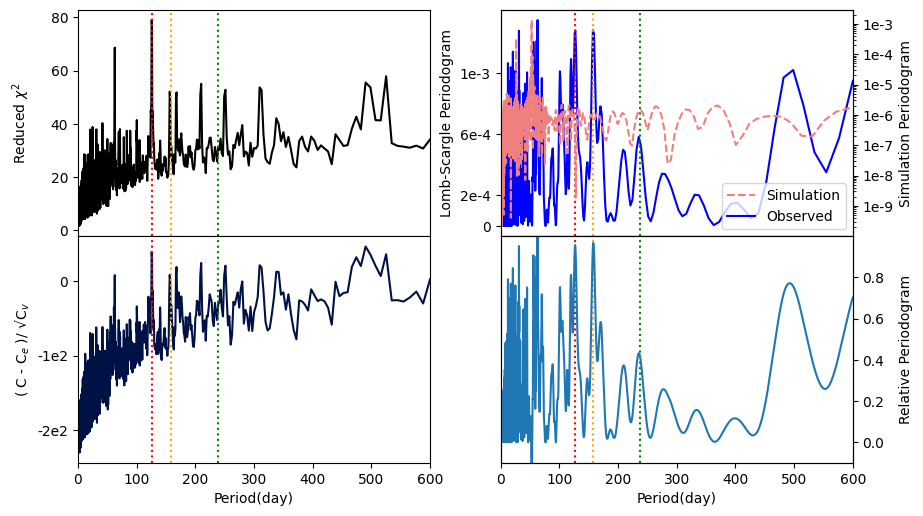

In [ ]:
"""
PART 5: Plot Sample A Results
=============================
Visualize Lomb-Scargle periodogram, chi-square, and C-statistic for Sample A.
"""

fig, axs = plt.subplots(figsize=(10, 6), dpi=100, sharex=True)
fig.subplots_adjust(wspace=None, hspace=0)

# ===============================
# Reduced Chi-Square (Top Left)
# ===============================

ax1 = plt.subplot(2, 2, 1)
ax1.plot(Period, chi2, label='χ²', color='black')
plt.ylabel('Reduced $\chi^2$')
plt.xlim([0, Pmax])
plt.xticks([])

# ===============================
# Lomb-Scargle Periodograms (Top Right)
# ===============================

ax2 = plt.subplot(2, 2, 2)
ax2.plot(1/frequency, power, label='Observed', color='blue')
plt.yticks([0, 2e-4, 6e-4, 1e-3], ['0', '2e-4', '6e-4', '1e-3'])
plt.ylabel('Lomb-Scargle Periodogram')

ax2r = ax2.twinx()
ax2r.set_yscale('log')
ax2r.plot(1/simu_frequency, simu_power, label='Simulation', linestyle='dashed', color='lightcoral')
ax2r.plot([1000], [0], label='Observed', color='blue')  # For legend
plt.yticks([1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9], 
           ['1e-3', '1e-4', '1e-5', '1e-6', '1e-7', '1e-8', '1e-9'])
plt.ylabel('Simulation Periodogram')
plt.xlim([0, Pmax])
plt.xticks([])
plt.legend(loc=4)

# ===============================
# C-Statistic (Bottom Left)
# ===============================

ax3 = plt.subplot(2, 2, 3)
ax3.plot(Period, cstat, label='C-statistic', color='#001146')
plt.xlabel('Period (day)')
plt.ylabel('(C - C$_{e}$) / √C$_{v}$')
plt.yticks([0, -100, -200], ['0', '-1e2', '-2e2'])
plt.xlim([0, Pmax])

# ===============================
# Relative Periodogram (Bottom Right)
# ===============================

ax4 = plt.subplot(2, 2, 4)
ax4r = ax4.twinx()
ax4r.plot(xnew, relative_power, color='#1f77b4')
plt.yticks(np.arange(0, 1, 0.2))
plt.ylabel('Relative Periodogram')
plt.ylim(-0.1, 1)
plt.xlim(0, Pmax)
plt.xlabel('Period (day)')
ax4.set_yticks([])

# ===============================
# Mark Candidate Periods
# ===============================

candidate_periods = [126.88, 158.15, 238]
colors = ['red', 'orange', 'green']

for period_val, color in zip(candidate_periods, colors):
    for axe in [ax1, ax2, ax3, ax4]:
        axe.axvline(period_val, color=color, linestyle='dotted', linewidth=1)

fig.align_ylabels([ax1, ax3, ax2r, ax4r])
plt.savefig('figure/sampleA.pdf', format='pdf', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Sample A figure saved: figure/sampleA.pdf")

In [ ]:
"""
PART 6: Periodogram Analysis - Sample B
========================================
Same analysis as Sample A but using all bursts (Sample B).
"""

print("Analyzing Sample B periodicity...")

# ========================
# Lomb-Scargle Periodogram
# ========================

min_period, max_period = 2, 600

frequency, power = LombScargle(times_B, norm_rates_B).autopower(
    minimum_frequency=1/max_period,
    maximum_frequency=1/min_period,
    normalization='standard'
)

# ========================
# Relative Periodogram
# ========================

Pmax = 600
Pmin = 2

index = np.where((Pmin <= 1/frequency) & (1/frequency <= Pmax))[0]
index_simu = np.where((Pmin <= 1/simu_frequency) & (1/simu_frequency <= Pmax))[0]

period_series = 1/frequency[index]
simu_period_series = 1/simu_frequency[index_simu]

max_abs_scaler = preprocessing.MaxAbsScaler()
norm_power = max_abs_scaler.fit_transform(power[index].reshape(-1, 1)).T[0]
norm_simu_power = max_abs_scaler.fit_transform(simu_power[index_simu].reshape(-1, 1)).T[0]

xnew = np.array(sorted(np.arange(Pmin, Pmax, 0.01), reverse=True))
func1 = interpolate.interp1d(period_series, norm_power, kind='cubic', fill_value="extrapolate")
func2 = interpolate.interp1d(simu_period_series, norm_simu_power, kind='cubic', fill_value="extrapolate")

power_new = func1(xnew)
simu_power_new = func2(xnew)
relative_power = power_new - simu_power_new

# ========================
# Statistical Tests
# ========================

phasebins = 20
fmax = 1 / Pmin
fmin = 1 / Pmax
fbin = 0.1 / (T100 - T0_A)

Frequency = np.arange(fmin, fmax + fbin, fbin)
Period = np.array(sorted([*map(lambda x: 1/x, Frequency)]))

Phi = []
chi2 = []
Exposures = []
cstat = []

for i in range(len(Period)):
    Phi.append(FoldPhase(mjd_sampleB, T0_B, Period[i]))
    Exposures.append(Exposure(mjd_ot, observe_time, index0_B, index1_B, T0_B, phasebins, Period[i]))
    chi2.append(PearsonChiSquare(phasebins, Phi[i], Period[i], Exposures[i]))
    cstat.append(Cstat(phasebins, Phi[i], Period[i], Exposures[i]))

# ========================
# Find Period Peaks
# ========================

peaks = argrelextrema(power, np.greater)[0]
period_peaks = 1/frequency[peaks]
peaks_in_range = period_peaks[np.where((period_peaks > 120) & (period_peaks < 160))]
print(f"Lomb-Scargle peaks (120-160 day): {peaks_in_range}")

peaks = argrelextrema(relative_power, np.greater)[0]
period_peaks = xnew[peaks]
peaks_in_range = period_peaks[np.where((period_peaks > 120) & (period_peaks < 600))]
print(f"Relative LS peaks (120-600 day): {peaks_in_range}")

peaks = argrelextrema(np.array(chi2), np.greater)[0]
period_peaks = Period[peaks]
peaks_in_range = period_peaks[np.where((period_peaks > 120) & (period_peaks < 160))]
print(f"Reduced χ² peaks (120-160 day): {peaks_in_range}")

peaks = argrelextrema(np.array(cstat), np.greater)[0]
period_peaks = Period[peaks]
peaks_in_range = period_peaks[np.where((period_peaks > 120) & (period_peaks < 160))]
print(f"C-statistic peaks (120-160 day): {peaks_in_range}")
print("✓ Sample B analysis complete")

LombScargle Peaks
  [158.56995057 146.98369689 126.89472093]
Relative LombScargle Peaks
  [488.16 398.89 331.09 280.73 235.34 209.57 187.07 170.35 158.11 147.3
 127.02]
ReducedChi2 Peaks
  [120.03265084 121.52055644 123.56277572 125.67480949 127.86029998
 131.28487464 135.51954535 138.71550979 140.70648274 145.58204769
 147.77656813 149.27671094 151.58491539 153.96562255 156.42230299]
Cstat 
  [120.03265084 121.52055644 122.53315742 123.56277572 125.67480949
 127.86029998 128.98179958 131.28487464 135.51954535 137.41920411
 138.71550979 140.70648274 145.58204769 147.77656813 149.27671094
 150.80762328 153.96562255 156.42230299]


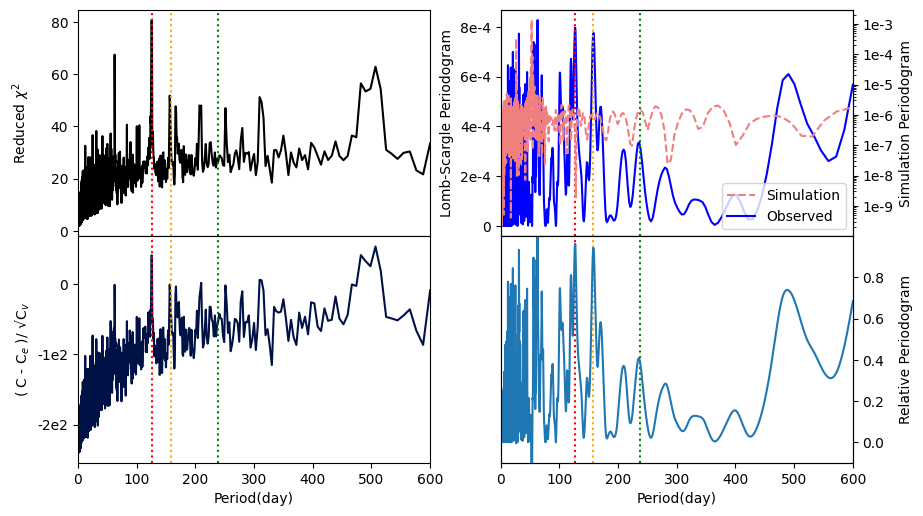

In [ ]:
"""
PART 7: Plot Sample B Results
=============================
Visualize Lomb-Scargle periodogram, chi-square, and C-statistic for Sample B.
"""

fig, axs = plt.subplots(figsize=(10, 6), dpi=100, sharex=True)
fig.subplots_adjust(wspace=None, hspace=0)

# ===============================
# Reduced Chi-Square (Top Left)
# ===============================

ax1 = plt.subplot(2, 2, 1)
ax1.plot(Period, chi2, label='χ²', color='black')
plt.ylabel('Reduced $\chi^2$')
plt.xlim([0, Pmax])
plt.xticks([])

# ===============================
# Lomb-Scargle Periodograms (Top Right)
# ===============================

ax2 = plt.subplot(2, 2, 2)
ax2.plot(1/frequency, power, label='Observed', color='blue')
plt.yticks([0, 2e-4, 4e-4, 6e-4, 8e-4], ['0', '2e-4', '4e-4', '6e-4', '8e-4'])
plt.ylabel('Lomb-Scargle Periodogram')

ax2r = ax2.twinx()
ax2r.set_yscale('log')
ax2r.plot(1/simu_frequency, simu_power, label='Simulation', linestyle='dashed', color='lightcoral')
ax2r.plot([1000], [0], label='Observed', color='blue')  # For legend
plt.yticks([1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9],
           ['1e-3', '1e-4', '1e-5', '1e-6', '1e-7', '1e-8', '1e-9'])
plt.ylabel('Simulation Periodogram')
plt.xlim([0, Pmax])
plt.xticks([])
plt.legend(loc=4)

# ===============================
# C-Statistic (Bottom Left)
# ===============================

ax3 = plt.subplot(2, 2, 3)
ax3.plot(Period, cstat, label='C-statistic', color='#001146')
plt.xlabel('Period (day)')
plt.ylabel('(C - C$_{e}$) / √C$_{v}$')
plt.yticks([0, -100, -200], ['0', '-1e2', '-2e2'])
plt.xlim([0, Pmax])

# ===============================
# Relative Periodogram (Bottom Right)
# ===============================

ax4 = plt.subplot(2, 2, 4)
ax4r = ax4.twinx()
ax4r.plot(xnew, relative_power, color='#1f77b4')
plt.yticks(np.arange(0, 1, 0.2))
plt.ylabel('Relative Periodogram')
plt.ylim(-0.1, 1)
plt.xlim(0, Pmax)
plt.xlabel('Period (day)')
ax4.set_yticks([])

# ===============================
# Mark Candidate Periods
# ===============================

candidate_periods = [126.88, 158.15, 238]
colors = ['red', 'orange', 'green']

for period_val, color in zip(candidate_periods, colors):
    for axe in [ax1, ax2, ax3, ax4]:
        axe.axvline(period_val, color=color, linestyle='dotted', linewidth=1)

fig.align_ylabels([ax1, ax3, ax2r, ax4r])
plt.savefig('figure/sampleB.pdf', format='pdf', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Sample B figure saved: figure/sampleB.pdf")

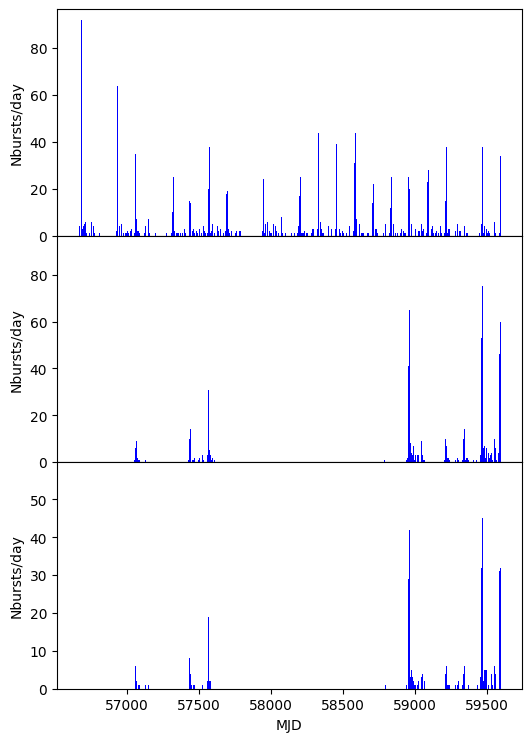

In [ ]:
"""
PART 8: Load Simulated Burst Results
====================================
Load pre-computed simulation results for three scenarios:
  1. NoGap: Continuous observation windows
  2. Gap: With observational gaps
  3. GapNoWin: Gaps without window effects
"""

print("Loading simulated burst data...")

# ========================
# Simulation Scenario 1: No Gap
# ========================

with open('T0_56658/SimulationBusrt_NoGap.pkl', "rb") as f:
    [simu_burst_series_nogap, simu_burst_times_nogap, simu_burst_norm_rates_nogap,
     simu_burst_frequency_nogap, simu_burst_power_nogap, Period_nogap,
     chi2_nogap, cstat_nogap] = pickle.load(f)

# ========================
# Simulation Scenario 2: Gap
# ========================

with open('T0_56658/SimulationBusrt_Gap.pkl', "rb") as f:
    [simu_burst_series_gap, simu_burst_times_gap, simu_burst_rm_rates_gap,
     simu_burst_frequency_gap, simu_burst_power_gap, Period_gap,
     chi2_gap, cstat_gap] = pickle.load(f)

# ========================
# Simulation Scenario 3: GapNoWin
# ========================

with open('T0_56658/SimulationBusrt_GapNoWin.pkl', "rb") as f:
    [simu_burst_series_gapnowin, simu_burst_times_gapnowin, simu_burst_rm_rates_gapnowin,
     simu_burst_frequency_gapnowin, simu_burst_power_gapnowin, Period_gapnowin,
     chi2_gapnowin, cstat_gapnowin] = pickle.load(f)

print("✓ Simulated burst data loaded successfully")

In [ ]:
"""
PART 9: Weighted Simulation Analysis
====================================
Combine results from 10 independent simulation runs using different random seeds.
This provides more robust estimates of statistical properties.
"""

print("Processing weighted simulation results...")

# ========================
# NoGap Scenario
# ========================

print("  - Processing NoGap scenario...")

Period_nogap = np.array(sorted(np.arange(Pmin, Pmax, 0.01), reverse=True))

simu_burst_frequency_nogap = []
simu_burst_power_nogap = []
chi2_nogap = []
cstat_nogap = []

for i in range(1, 11):
    with open(f'T0_56658/SimulationBusrt_NoGap_{i:02d}.pkl', "rb") as f:
        [simu_burst_series, simu_burst_times, simu_burst_norm_rates,
         simu_burst_frequency, simu_burst_power, Period, chi2, cstat] = pickle.load(f)
        
        simu_burst_frequency_nogap.append(simu_burst_frequency)
        simu_burst_power_nogap.append(simu_burst_power)
        
        # Interpolate chi2 to common period grid
        func1 = interpolate.interp1d(Period, chi2, kind='cubic', fill_value="extrapolate")
        chi2_nogap.append(func1(Period_nogap))
        
        # Interpolate cstat (handle NaNs)
        cstat = np.nan_to_num(cstat, nan=np.min(np.array(cstat)[~np.isnan(cstat)]))
        func2 = interpolate.interp1d(Period, cstat, kind='cubic', fill_value="extrapolate")
        cstat_nogap.append(func2(Period_nogap))

# Average over 10 runs
simu_burst_frequency_nogap = np.mean(simu_burst_frequency_nogap, axis=0)
simu_burst_power_nogap = np.mean(simu_burst_power_nogap, axis=0)
chi2_nogap = np.mean(chi2_nogap, axis=0)
cstat_nogap = np.mean(cstat_nogap, axis=0)

# ========================
# Gap Scenario
# ========================

print("  - Processing Gap scenario...")

Period_gap = np.array(sorted(np.arange(Pmin, Pmax, 0.01), reverse=True))

simu_burst_frequency_gap = []
simu_burst_power_gap = []
chi2_gap = []
cstat_gap = []

for i in range(1, 11):
    with open(f'T0_56658/SimulationBusrt_Gap_{i:02d}.pkl', "rb") as f:
        [simu_burst_series, simu_burst_times, simu_burst_norm_rates,
         simu_burst_frequency, simu_burst_power, Period, chi2, cstat] = pickle.load(f)
        
        simu_burst_frequency_gap.append(simu_burst_frequency)
        simu_burst_power_gap.append(simu_burst_power)
        
        func1 = interpolate.interp1d(Period, chi2, kind='cubic', fill_value="extrapolate")
        chi2_gap.append(func1(Period_gap))
        
        cstat = np.nan_to_num(cstat, nan=np.min(np.array(cstat)[~np.isnan(cstat)]))
        func2 = interpolate.interp1d(Period, cstat, kind='cubic', fill_value="extrapolate")
        cstat_gap.append(func2(Period_gap))

simu_burst_frequency_gap = np.mean(simu_burst_frequency_gap, axis=0)
simu_burst_power_gap = np.mean(simu_burst_power_gap, axis=0)
chi2_gap = np.mean(chi2_gap, axis=0)
cstat_gap = np.mean(cstat_gap, axis=0)

# ========================
# GapNoWin Scenario
# ========================

print("  - Processing GapNoWin scenario...")

Period_gapnowin = np.array(sorted(np.arange(Pmin, Pmax, 0.01), reverse=True))

simu_burst_frequency_gapnowin = []
simu_burst_power_gapnowin = []
chi2_gapnowin = []
cstat_gapnowin = []

for i in range(1, 11):
    with open(f'T0_56658/SimulationBusrt_GapNoWin_{i:02d}.pkl', "rb") as f:
        [simu_burst_series, simu_burst_times, simu_burst_norm_rates,
         simu_burst_frequency, simu_burst_power, Period, chi2, cstat] = pickle.load(f)
        
        simu_burst_frequency_gapnowin.append(simu_burst_frequency)
        simu_burst_power_gapnowin.append(simu_burst_power)
        
        func1 = interpolate.interp1d(Period, chi2, kind='cubic', fill_value="extrapolate")
        chi2_gapnowin.append(func1(Period_gapnowin))
        
        cstat = np.nan_to_num(cstat, nan=np.min(np.array(cstat)[~np.isnan(cstat)]))
        func2 = interpolate.interp1d(Period, cstat, kind='cubic', fill_value="extrapolate")
        cstat_gapnowin.append(func2(Period_gapnowin))

simu_burst_frequency_gapnowin = np.mean(simu_burst_frequency_gapnowin, axis=0)
simu_burst_power_gapnowin = np.mean(simu_burst_power_gapnowin, axis=0)
chi2_gapnowin = np.mean(chi2_gapnowin, axis=0)
cstat_gapnowin = np.mean(cstat_gapnowin, axis=0)

print("✓ Weighted simulation analysis complete")

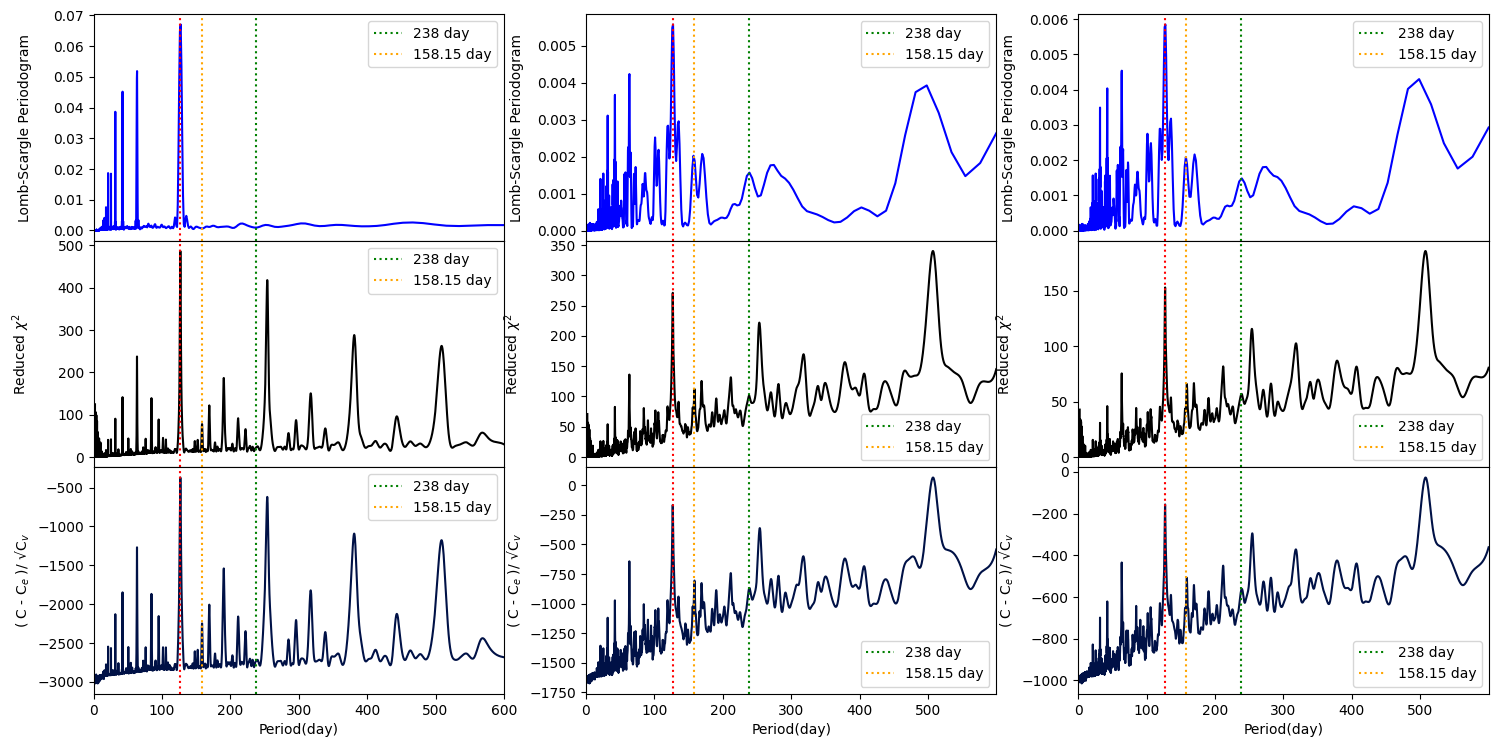

In [ ]:
"""
PART 10: Comparison of Simulation Scenarios
===========================================
Visualize periodogram and statistics across three observational scenarios.
"""

fig, axs = plt.subplots(figsize=(18, 9), dpi=100, sharex=True)
fig.subplots_adjust(hspace=0)

# ========================
# NoGap Scenario (Left Column)
# ========================

print("Plotting simulation scenarios...")

ax1 = plt.subplot(3, 3, 1)
ax1.plot(1/simu_burst_frequency_nogap, simu_burst_power_nogap, color='blue')
ax1.axvline(238, ls=':', c='green', label='238 day')
ax1.axvline(158.15, ls=':', c='orange', label='158.15 day')
ax1.axvline(126.88, ls=':', c='red', linewidth=0.8)
plt.xlim(0, Pmax)
plt.ylabel('Lomb-Scargle Periodogram')
plt.legend(loc=1, fontsize=8)
plt.xticks([])
plt.title('NoGap Scenario', fontsize=10)

ax2 = plt.subplot(3, 3, 4)
ax2.plot(Period_nogap, chi2_nogap, color='black')
ax2.axvline(238, ls=':', c='green')
ax2.axvline(158.15, ls=':', c='orange')
ax2.axvline(126.88, ls=':', c='red', linewidth=0.8)
plt.xlim(0, Pmax)
plt.ylabel('Reduced $\chi^2$')
plt.xticks([])
plt.legend(loc=1, fontsize=8)

ax3 = plt.subplot(3, 3, 7)
ax3.plot(Period_nogap, cstat_nogap, color='#001146')
ax3.axvline(238, ls=':', c='green')
ax3.axvline(158.15, ls=':', c='orange')
ax3.axvline(126.88, ls=':', c='red', linewidth=0.8)
plt.xlim(0, Pmax)
plt.ylabel('(C - C$_{e}$) / √C$_{v}$')
plt.xlabel('Period (day)')
plt.legend(loc=1, fontsize=8)

# ========================
# GapNoWin Scenario (Middle Column)
# ========================

ax4 = plt.subplot(3, 3, 2)
ax4.plot(1/simu_burst_frequency_gapnowin, simu_burst_power_gapnowin, color='blue')
ax4.axvline(238, ls=':', c='green', label='238 day')
ax4.axvline(158.15, ls=':', c='orange', label='158.15 day')
ax4.axvline(126.88, ls=':', c='red', linewidth=0.8)
plt.xlim(0, Pmax)
plt.ylabel('Lomb-Scargle Periodogram')
plt.legend(loc=1, fontsize=8)
plt.xticks([])
plt.title('GapNoWin Scenario', fontsize=10)

ax5 = plt.subplot(3, 3, 5)
ax5.plot(Period_gapnowin, chi2_gapnowin, color='black')
ax5.axvline(238, ls=':', c='green')
ax5.axvline(158.15, ls=':', c='orange')
ax5.axvline(126.88, ls=':', c='red', linewidth=0.8)
plt.xlim(0, Pmax)
plt.ylabel('Reduced $\chi^2$')
plt.xticks([])
plt.legend(loc=4, fontsize=8)

ax6 = plt.subplot(3, 3, 8)
ax6.plot(Period_gapnowin, cstat_gapnowin, color='#001146')
ax6.axvline(238, ls=':', c='green')
ax6.axvline(158.15, ls=':', c='orange')
ax6.axvline(126.88, ls=':', c='red', linewidth=0.8)
plt.xticks([0, 100, 200, 300, 400, 500])
plt.xlim(0, Pmax)
plt.xlabel('Period (day)')
plt.ylabel('(C - C$_{e}$) / √C$_{v}$')
plt.legend(loc=4, fontsize=8)

# ========================
# Gap Scenario (Right Column)
# ========================

ax7 = plt.subplot(3, 3, 3)
ax7.plot(1/simu_burst_frequency_gap, simu_burst_power_gap, color='blue')
ax7.axvline(238, ls=':', c='green', label='238 day')
ax7.axvline(158.15, ls=':', c='orange', label='158.15 day')
ax7.axvline(126.88, ls=':', c='red', linewidth=0.8)
plt.xlim(0, Pmax)
plt.ylabel('Lomb-Scargle Periodogram')
plt.legend(loc=1, fontsize=8)
plt.xticks([])
plt.title('Gap Scenario', fontsize=10)

ax8 = plt.subplot(3, 3, 6)
ax8.plot(Period_gap, chi2_gap, color='black')
ax8.axvline(238, ls=':', c='green')
ax8.axvline(158.15, ls=':', c='orange')
ax8.axvline(126.88, ls=':', c='red', linewidth=0.8)
plt.xlim(0, Pmax)
plt.ylabel('Reduced $\chi^2$')
plt.xticks([])
plt.legend(loc=4, fontsize=8)

ax9 = plt.subplot(3, 3, 9)
ax9.plot(Period_gap, cstat_gap, color='#001146')
ax9.axvline(238, ls=':', c='green')
ax9.axvline(158.15, ls=':', c='orange')
ax9.axvline(126.88, ls=':', c='red', linewidth=0.8)
plt.xticks([0, 100, 200, 300, 400, 500])
plt.xlim(0, Pmax)
plt.xlabel('Period (day)')
plt.ylabel('(C - C$_{e}$) / √C$_{v}$')
plt.legend(loc=4, fontsize=8)

fig.align_ylabels([ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9])
plt.savefig('figure/simu_bursts_pt.pdf', dpi=100, format='pdf', bbox_inches='tight')
plt.show()

print("✓ Simulation comparison figure saved: figure/simu_bursts_pt.pdf")

Period: 126.88 Wactive: 44.407999999999994 Phase Bins: 20
Error: 2.0463892759482567
Bayesian Block:
 [0.    0.075 0.125 0.175 0.375 0.725 0.775 0.95 ]


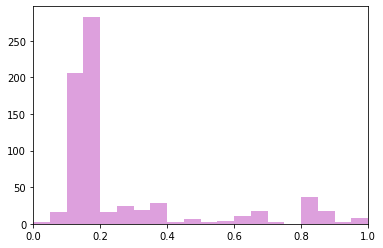

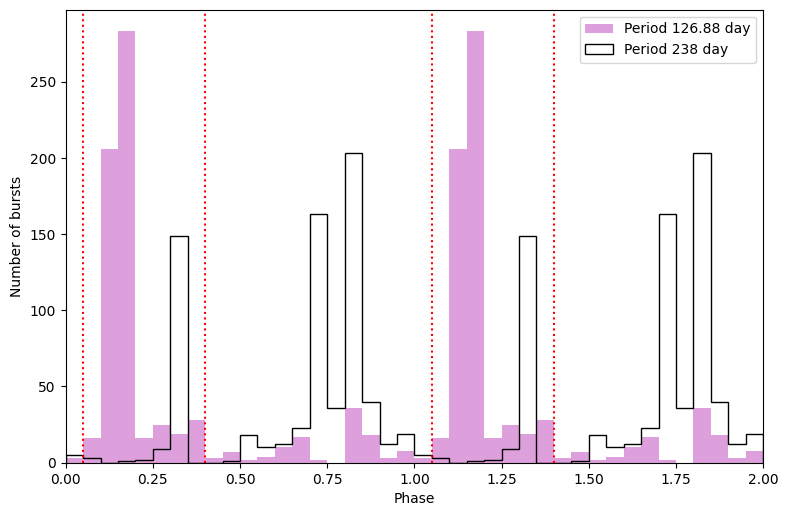

In [ ]:
"""
PART 11: Phase Folding Analysis
===============================
Fold burst times modulo candidate periods and analyze phase distribution.
Uses Bayesian blocks for optimal binning.
"""

print("Performing phase folding analysis...")

# ========================
# Analysis Parameters
# ========================

period = 126.88  # Primary candidate period
phasebins = 20
Wactive = period * 0.35  # Active phase width

mjd_for_phasefold = mjd_sampleA
phase = FoldPhase(mjd_for_phasefold, T0_A, period)
phase2 = np.hstack([phase, phase + 1])  # Duplicate for periodic visualization

# ========================
# Histogram and Bayesian Blocks
# ========================

numbers, bins = np.histogram(phase, bins=np.arange(0., 1. + 1./phasebins, 1./phasebins))
edges = bayesian_blocks(bins[:-1], numbers, sigma=np.sqrt(numbers), fitness='events', p0=0.01)
bay_num, bay_bins = np.histogram(phase2, weights=None, bins=np.hstack([edges, edges + 1]))

print(f"Period: {period} day")
print(f"Active phase width: {Wactive} day")
print(f"Error: {period * Wactive / (mjd_for_phasefold[-1] - mjd_for_phasefold[0]):.4f}")
print(f"Bayesian Block edges: {edges}")

# ========================
# Compare with 238-day Period
# ========================

phase_zou = FoldPhase(mjd_sampleA, T0_A, 238)
phase_zou2 = np.hstack([phase_zou, phase_zou + 1])

# ========================
# Plot Phase Folding Results
# ========================

fig = plt.figure(figsize=(9, 6), dpi=100)
plt.hist(x=phase2, bins=np.arange(0., 2. + 1./phasebins, 1./phasebins),
         color='plum', label=f'Period {period} day')
plt.hist(x=phase_zou2, bins=np.arange(0., 2. + 1./phasebins, 1./phasebins),
         histtype='step', color='black', linewidth=1.5, label='Period 238 day')

# Mark active phase regions
for ver_line in [0.05, 0.4, 1.05, 1.4]:
    plt.axvline(ver_line, ls=':', c='red', linewidth=1)

plt.xlim(0, 2)
plt.xlabel('Phase', fontsize=12)
plt.ylabel('Number of bursts', fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.savefig('figure/phase.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("✓ Phase folding analysis complete")
print("✓ Phase folding figure saved: figure/phase.pdf")

Period:  126.88


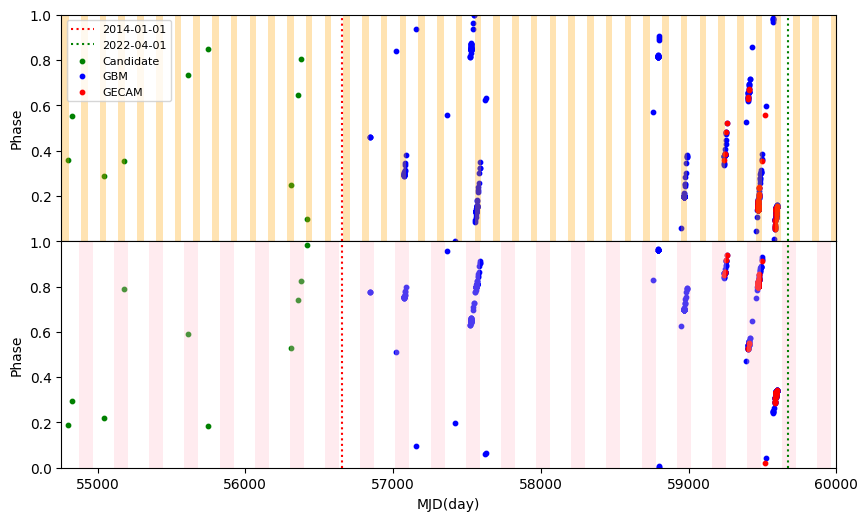

In [ ]:
"""
PART 12: Burst Phase Distribution Over Time
============================================
Visualize burst phase distribution folded at candidate periods.
Identify active phases and temporal evolution.
"""

print("Analyzing burst phase distribution...")

# ========================
# Time and Period Parameters
# ========================

T_Start = 54754.8       # Reference epoch (2008-10-15)
T_End = 60000           # End time (2023-02-25)
period = 126.88         # Primary candidate period
main_phase = [0.05, 0.4]  # Active phase range

# ========================
# Classify Bursts
# ========================

mjd_candidate = mjd_for_plot[np.where(flag == 'Candidate')[0]]
mjd_gbm = mjd_for_plot[np.where((flag == 'GBM') | (flag == 'GBM,GECAM'))[0]]
mjd_gecam = mjd_for_plot[np.where((flag == 'GECAM') | (flag == 'GBM,GECAM'))[0]]

# Fold phases
phases_candidate = FoldPhase(mjd_candidate, T_Start, period)
phases_gbm = FoldPhase(mjd_gbm, T_Start, period)
phases_gecam = FoldPhase(mjd_gecam, T_Start, period)

print(f"Period: {period} day")
print(f"Burst counts - Candidate: {len(mjd_candidate)}, GBM: {len(mjd_gbm)}, GECAM: {len(mjd_gecam)}")

# ========================
# Plot Phase vs Time
# ========================

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
fig.subplots_adjust(wspace=0, hspace=0)

# --------
# Period 1 (126.88 day)
# --------

plt.subplot(2, 1, 1)
plt.scatter(mjd_candidate, phases_candidate, s=10, label='Candidate', color='green', alpha=0.6)
plt.scatter(mjd_gbm, phases_gbm, s=10, label='GBM', color='blue', alpha=0.6)
plt.scatter(mjd_gecam, phases_gecam, s=10, label='GECAM', color='red', alpha=0.6)

# Mark significant epochs
plt.axvline(56658, ls=':', c='red', linewidth=1, label='2014-01-01')
plt.axvline(59670, ls=':', c='green', linewidth=1, label='2022-04-01')

# Shade active phase regions
for i in np.arange(T_Start, T_End + period, period):
    plt.axvspan(i + period * main_phase[0], i + period * main_phase[1],
                facecolor='orange', alpha=0.2)

plt.xlabel('MJD (day)', fontsize=11)
plt.ylabel('Phase', fontsize=11)
plt.xlim(T_Start, T_End)
plt.ylim(0, 1)
plt.xticks([])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=10)
plt.legend(loc=1, fontsize=8)
plt.title(f'Period: {period} day', fontsize=11)
plt.grid(axis='y', alpha=0.3)

# --------
# Period 2 (238 day)
# --------

plt.subplot(2, 1, 2)
phases_candidate_238 = FoldPhase(mjd_candidate, T_Start, 238)
phases_gbm_238 = FoldPhase(mjd_gbm, T_Start, 238)
phases_gecam_238 = FoldPhase(mjd_gecam, T_Start, 238)

plt.scatter(mjd_candidate, phases_candidate_238, s=10, label='Candidate', color='green', alpha=0.6)
plt.scatter(mjd_gbm, phases_gbm_238, s=10, label='GBM', color='blue', alpha=0.6)
plt.scatter(mjd_gecam, phases_gecam_238, s=10, label='GECAM', color='red', alpha=0.6)

plt.axvline(56658, ls=':', c='red', linewidth=1, label='2014-01-01')
plt.axvline(59670, ls=':', c='green', linewidth=1, label='2022-04-01')

# Shade active phase regions for 238-day period
for i in np.arange(T_Start, T_End + 238, 238):
    plt.axvspan(i + 238 * 0.5, i + 238 * 0.9, facecolor='pink', alpha=0.2)

plt.xlabel('MJD (day)', fontsize=11)
plt.ylabel('Phase', fontsize=11)
plt.xlim(T_Start, T_End)
plt.ylim(0, 1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0], fontsize=10)
plt.title('Period: 238 day', fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.savefig('figure/burst_phase.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("✓ Burst phase distribution figure saved: figure/burst_phase.pdf")

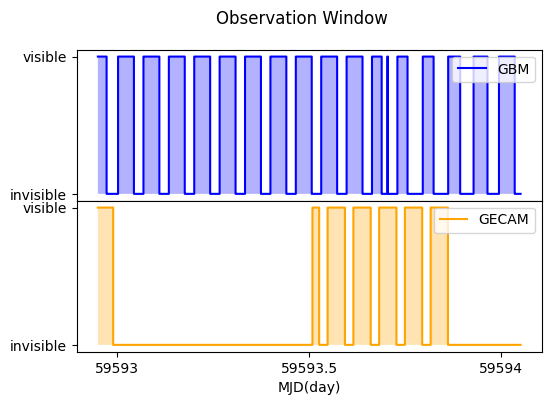

In [ ]:
"""
PART 13: Observation Window Visualization
==========================================
Visualize observation windows and visibility for GBM and GECAM instruments.
"""

import numpy as np
import matplotlib.pyplot as plt

print("Plotting observation windows...")

# ========================
# Observation Window Data
# ========================

# Individual burst detection times
GBM_GECAM = [59593.820935567, 59593.823009803]
GECAM = [59593.168248032, 59593.831165509, 59593.837585648, 59593.838229745,
         59593.842190972, 59593.844379629, 59593.847976273, 59593.849715277,
         59593.851971064, 59593.853556134, 59593.855438657]
GBM = [59593.026604212, 59593.168497777, 59593.276351145, 59593.344459756,
       59593.476883726, 59593.485900509, 59593.557705925, 59593.565626886,
       59593.672723356, 59593.810609618, 59593.861978067, 59593.865468101,
       59593.865480439, 59593.865659062, 59593.872540763, 59593.931589814,
       59593.931635775, 59593.943359502, 59593.949247291]

# Observation windows
GBM_win_start = [59592.54002, 59592.6061, 59592.67218, 59592.71188, 59592.73826,
                 59592.80434, 59592.87041, 59592.93649, 59593.00257, 59593.06865,
                 59593.13473, 59593.20081, 59593.26688, 59593.33296, 59593.39904,
                 59593.46511, 59593.53119, 59593.59728, 59593.66335, 59593.70305,
                 59593.72943, 59593.79551, 59593.86158, 59593.92766, 59593.99374,
                 59594.05981, 59594.12589, 59594.19196, 59594.25804, 59594.32412,
                 59594.39019, 59594.45627, 59594.52235]
GBM_win_end = [59592.5814, 59592.64749, 59592.69818, 59592.71356, 59592.76538,
               59592.83321, 59592.90207, 59592.97275, 59593.04384, 59593.11005,
               59593.17614, 59593.24222, 59593.30831, 59593.37438, 59593.44047,
               59593.50655, 59593.57264, 59593.63871, 59593.68852, 59593.7048,
               59593.75583, 59593.82367, 59593.89282, 59593.96386, 59594.03473,
               59594.10129, 59594.16738, 59594.23346, 59594.29955, 59594.36562,
               59594.43171, 59594.49779, 59594.56387]

GECAM_win_start = [59592.57167, 59592.6092, 59592.67625, 59592.7433, 59592.81034,
                   59592.87738, 59592.94443, 59593.50837, 59593.54784, 59593.61488,
                   59593.68192, 59593.74897, 59593.81601, 59594.31994, 59594.36845,
                   59594.43834, 59594.50781, 59594.55344]
GECAM_win_end = [59592.58775, 59592.65478, 59592.72178, 59592.7888, 59592.85582,
                 59592.92282, 59592.98984, 59593.52594, 59593.59295, 59593.65997,
                 59593.72697, 59593.79398, 59593.861, 59594.33006, 59594.39707,
                 59594.45696, 59594.53109, 59594.59809]

# ========================
# Create Time Grid
# ========================

x = np.round(np.arange(59592.95, 59594.05 + 1e-5, 1e-5), 5)
y_gbm = np.zeros(len(x))
y_gecam = np.zeros(len(x))

# Mark observation windows
for i in range(len(GBM_win_start)):
    y_gbm[np.where((GBM_win_start[i] <= x) & (x < GBM_win_end[i]))[0]] = 1

for j in range(len(GECAM_win_start)):
    y_gecam[np.where((GECAM_win_start[j] <= x) & (x < GECAM_win_end[j]))[0]] = 1

# ========================
# Plot Observation Windows
# ========================

fig, axs = plt.subplots(figsize=(6, 4), dpi=100, sharex=True)
fig.subplots_adjust(hspace=0)

plt.subplot(2, 1, 1)
plt.step(x, y_gbm, where='post', color='blue', linewidth=1.5, label='GBM')
plt.fill_between(x, 0, y_gbm, facecolor='blue', alpha=0.3, step='post')
plt.xticks([59593, 59593.5, 59594], ['59593', '59593.5', '59594'])
plt.yticks([0, 1], ['invisible', 'visible'], fontsize=10)
plt.legend(loc=1, fontsize=10)
plt.ylabel('GBM Status', fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 1, 2)
plt.step(x, y_gecam, where='post', color='orange', linewidth=1.5, label='GECAM')
plt.fill_between(x, 0, y_gecam, facecolor='orange', alpha=0.3, step='post')
plt.xticks([59593, 59593.5, 59594], ['59593', '59593.5', '59594'])
plt.yticks([0, 1], ['invisible', 'visible'], fontsize=10)
plt.xlabel('MJD (day)', fontsize=10)
plt.ylabel('GECAM Status', fontsize=10)
plt.suptitle('Observation Windows', fontsize=12, y=0.98)
plt.legend(loc=1, fontsize=10)
plt.grid(axis='y', alpha=0.3)

plt.savefig('figure/OW.pdf', format='pdf', bbox_inches='tight')
plt.show()

print("✓ Observation window figure saved: figure/OW.pdf")